# Dataset

I use the CIFAR-10 dataset. It has small color images in 10 classes.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# These are the class names in CIFAR-10.
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Download and load CIFAR-10 from Keras.
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Count the number of classes.
num_classes = len(class_names)

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", num_classes)

d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10


# Exploratory Data Analysis

Now we look at some images and count how many images each class has.

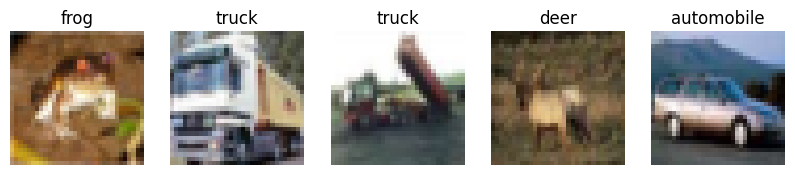

In [53]:
# Show 5 sample images from the training data.
plt.figure(figsize=(10, 2))

for i in range(5):
    label_index = y_train[i][0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[label_index])
    plt.axis("off")

plt.show()

Images per class:
airplane: train=5000, test=1000, total=6000
automobile: train=5000, test=1000, total=6000
bird: train=5000, test=1000, total=6000
cat: train=5000, test=1000, total=6000
deer: train=5000, test=1000, total=6000
dog: train=5000, test=1000, total=6000
frog: train=5000, test=1000, total=6000
horse: train=5000, test=1000, total=6000
ship: train=5000, test=1000, total=6000
truck: train=5000, test=1000, total=6000


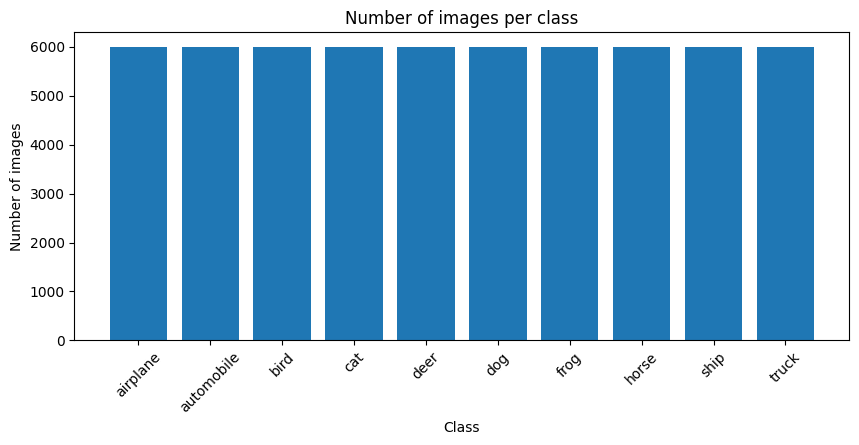

In [54]:
# Count images in each class for train and test data.
train_counts = np.bincount(y_train.flatten(), minlength=num_classes)
test_counts = np.bincount(y_test.flatten(), minlength=num_classes)
total_counts = train_counts + test_counts

print("Images per class:")
for i, name in enumerate(class_names):
    print(f"{name}: train={train_counts[i]}, test={test_counts[i]}, total={total_counts[i]}")

# Show the total number of images per class in a bar chart.
plt.figure(figsize=(10, 4))
plt.bar(class_names, total_counts)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

The images are small color images. Each image is 32 by 32 pixels. We can see objects like animals, cars, ships, and planes. The classes have the same number of images, so the dataset is balanced.

# Preprocessing

We prepare the data before using it in a CNN model.

In [55]:
# Change pixel values from 0-255 to 0-1.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Change labels to one-hot form for classification.
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# CIFAR-10 already gives us train and test sets.
print("Train data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("One-hot train labels shape:", y_train_cat.shape)
print("One-hot test labels shape:", y_test_cat.shape)

Train data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
One-hot train labels shape: (50000, 10)
One-hot test labels shape: (10000, 10)


# Convultional Networks With Keras

Now it is time to test CNN models with Keras. We use a small wrapper function, like in the lab, to build models from simple layer names.

In [56]:
import pandas as pd
import tensorflow as tf

from tensorflow.keras import callbacks, initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.regularizers import l1, l2, l1_l2
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# Early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,          # Minimum change to count as better.
    patience=5,               # Stop if there is no good change.
    restore_best_weights=True,
)

### Small Name Fix

The lab uses names like `X_train` and `y_train_enc`. My earlier cells may use names like `x_train` and `y_train_cat`. We make both styles work here.

In [57]:
# Use lab-style names if earlier cells used lowercase names.
if 'X_train' not in globals() and 'x_train' in globals():
  X_train = x_train

if 'X_test' not in globals() and 'x_test' in globals():
  X_test = x_test

if 'y_train_enc' not in globals() and 'y_train_cat' in globals():
  y_train_enc = y_train_cat

if 'y_test_enc' not in globals() and 'y_test_cat' in globals():
  y_test_enc = y_test_cat

print('Train data shape:', X_train.shape)
print('Train encoded labels shape:', y_train_enc.shape)

Train data shape: (50000, 32, 32, 3)
Train encoded labels shape: (50000, 10)


### Some Handy Functions

First, let's reuse the wrapper functions from the lab. These functions help us create a model and read the results.

In [58]:
def plot_history(history, plot_type: str='loss'):
  hist_df = pd.DataFrame(history.history)
  plt.figure(figsize=(20, 8))
  colors = []
  columns_to_plot = []
  labels = []

  for col_name in hist_df.columns:
    # Define colors.
    if 'val' in col_name:
      color_base = 'r'
      label_base = 'Validation'
    else:
      color_base = 'b'
      label_base = 'Training'

    if plot_type == 'loss':
      if 'loss' in col_name:
        labels.append(label_base)
        columns_to_plot.append(col_name)
        colors.append(color_base)
    else:
      if 'loss' in col_name:
        continue
      if 'accuracy' in col_name or 'acc' in col_name:
        label = label_base + ' Accuracy'
      else:
        label = label_base + ' ' + col_name

      labels.append(label)
      columns_to_plot.append(col_name)
      colors.append(color_base)

  for itr in range(0, len(columns_to_plot)):
    plt.plot(hist_df.loc[:, [columns_to_plot[itr]]], colors[itr], label=labels[itr], lw=4)

  plt.ylabel(plot_type)
  plt.xlabel('Epochs')
  plt.legend(loc='best')
  plt.show()

In [59]:
def create_model(hidden_layers: list=['Conv2D_3x3_10_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_20_1', 'AveragePooling2D_2x2_1', 'Flatten', 'Dense_30'],
                 input_size=None, no_classes=None, activation_func: str='relu',
                 l1_reg: float=0.0, l2_reg: float=0.0,
                 learning_rate: float=0.001, learning_rate_decay: float=0.95,
                 dropout_rate: float=0.0, weight_initializer: str='',
                 optimizer_name: str='adam', regularization_type: str='kernel_regularizer'):

  # Get shapes after the data cells have run.
  if input_size is None:
    input_size = X_train.shape[1:]
  if no_classes is None:
    no_classes = y_train_enc.shape[1]

  # Setup the weight initialization techniques.
  if weight_initializer == 'RandomNormal':
    weight_initializer = initializers.RandomNormal()
  elif weight_initializer == 'RandomUniform':
    weight_initializer = initializers.RandomUniform()
  elif weight_initializer == 'Zeros':
    weight_initializer = initializers.Zeros()
  elif weight_initializer == 'GlorotUniform':
    weight_initializer = initializers.GlorotUniform()
  elif weight_initializer == 'GlorotNormal':
    weight_initializer = initializers.GlorotNormal()
  else:
    weight_initializer = None

  # Setup regularization.
  regularizer = None
  if l1_reg and l2_reg:
    regularizer = l1_l2(l1=l1_reg, l2=l2_reg)
  elif l1_reg:
    regularizer = l1(l1_reg)
  elif l2_reg:
    regularizer = l2(l2_reg)

  model = Sequential()
  model.add(Input(shape=input_size))

  # Add hidden layers.
  itr = 0
  for layer in hidden_layers:
    layer_specs = layer.split('_')
    layer_type = layer_specs[0]

    if layer_type == 'Dense':
      n_l = int(layer_specs[1])
      layer_params = {
          'activation': activation_func,
          'kernel_initializer': weight_initializer,
      }
      if regularizer is not None:
        layer_params[regularization_type] = regularizer
      model.add(Dense(n_l, **layer_params))

    elif layer_type == 'Flatten':
      model.add(Flatten())

    elif layer_type == 'Conv2D':
      kernel_size = tuple(int(v) for v in layer_specs[1].split('x'))
      filters = int(layer_specs[2])
      stride = int(layer_specs[3])
      layer_params = {
          'filters': filters,
          'kernel_size': kernel_size,
          'activation': activation_func,
          'kernel_initializer': weight_initializer,
      }
      if stride:
        layer_params['strides'] = stride
      if regularizer is not None:
        layer_params[regularization_type] = regularizer
      model.add(Conv2D(**layer_params))

    elif layer_type in ['MaxPooling2D', 'AveragePooling2D']:
      pool_size = tuple(int(v) for v in layer_specs[1].split('x'))
      stride = int(layer_specs[2])
      layer_params = {'pool_size': pool_size}
      if stride:
        layer_params['strides'] = stride
      if layer_type == 'MaxPooling2D':
        model.add(MaxPooling2D(**layer_params))
      else:
        model.add(AveragePooling2D(**layer_params))

    if dropout_rate and itr % 2 == 0 and layer_type not in ['Flatten', 'MaxPooling2D', 'AveragePooling2D']:
      model.add(Dropout(dropout_rate))

    itr += 1

  # Add the last layer.
  model.add(Dense(no_classes, activation='softmax'))

  # Next, let's compile it.
  if optimizer_name == 'sgd':
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  elif optimizer_name == 'RMSprop':
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
  elif optimizer_name == 'Adadelta':
    optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate, rho=learning_rate_decay)
  else:
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=learning_rate_decay)

  model.compile(
      loss='categorical_crossentropy',
      optimizer=optimizer,
      metrics=['accuracy'],
  )

  return model

In [60]:
def convert_predictions(predictions):
  output = np.argmax(predictions, axis=1)
  return output

### Building the Model

So a simple CNN model would be built like this.

In [61]:
baseline_architecture = [
    'Conv2D_3x3_32_1',
    'MaxPooling2D_2x2_0',
    'Conv2D_3x3_64_1',
    'MaxPooling2D_2x2_0',
    'Conv2D_3x3_64_1',
    'Flatten',
    'Dense_64',
    'Dense_32',
]

model = create_model(hidden_layers=baseline_architecture,
                     activation_func='relu',
                     learning_rate=0.001,
                     dropout_rate=0.2)

model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_108 (Conv2D)             │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_140 (Dropout)           │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_141 (Dropout)           │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_142 (Dropout)           │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_41 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_143 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,330 (485.66 KB)

 Trainable params: 124,330 (485.66 KB)

 Non-trainable params: 0 (0.00 B)

Now we train the model. We use a small number of epochs so it can run on a normal local machine.

In [62]:
history = model.fit(X_train, y_train_enc,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=2)

Epoch 1/10
625/625 - 9s - 14ms/step - accuracy: 0.3095 - loss: 1.8096 - val_accuracy: 0.4098 - val_loss: 1.6048
Epoch 2/10
625/625 - 7s - 11ms/step - accuracy: 0.4627 - loss: 1.4591 - val_accuracy: 0.5219 - val_loss: 1.3721
Epoch 3/10
625/625 - 7s - 11ms/step - accuracy: 0.5286 - loss: 1.3100 - val_accuracy: 0.5722 - val_loss: 1.2820
Epoch 4/10
625/625 - 7s - 11ms/step - accuracy: 0.5615 - loss: 1.2237 - val_accuracy: 0.5756 - val_loss: 1.2128
Epoch 5/10
625/625 - 11s - 18ms/step - accuracy: 0.5875 - loss: 1.1559 - val_accuracy: 0.5979 - val_loss: 1.1629
Epoch 6/10
625/625 - 26s - 42ms/step - accuracy: 0.6071 - loss: 1.0990 - val_accuracy: 0.5982 - val_loss: 1.1229
Epoch 7/10
625/625 - 10s - 17ms/step - accuracy: 0.6255 - loss: 1.0573 - val_accuracy: 0.6624 - val_loss: 0.9821
Epoch 8/10
625/625 - 7s - 12ms/step - accuracy: 0.6431 - loss: 1.0065 - val_accuracy: 0.6627 - val_loss: 0.9856
Epoch 9/10
625/625 - 7s - 12ms/step - accuracy: 0.6539 - loss: 0.9810 - val_accuracy: 0.6427 - val_lo

The next plots show how the loss and accuracy changed during training.

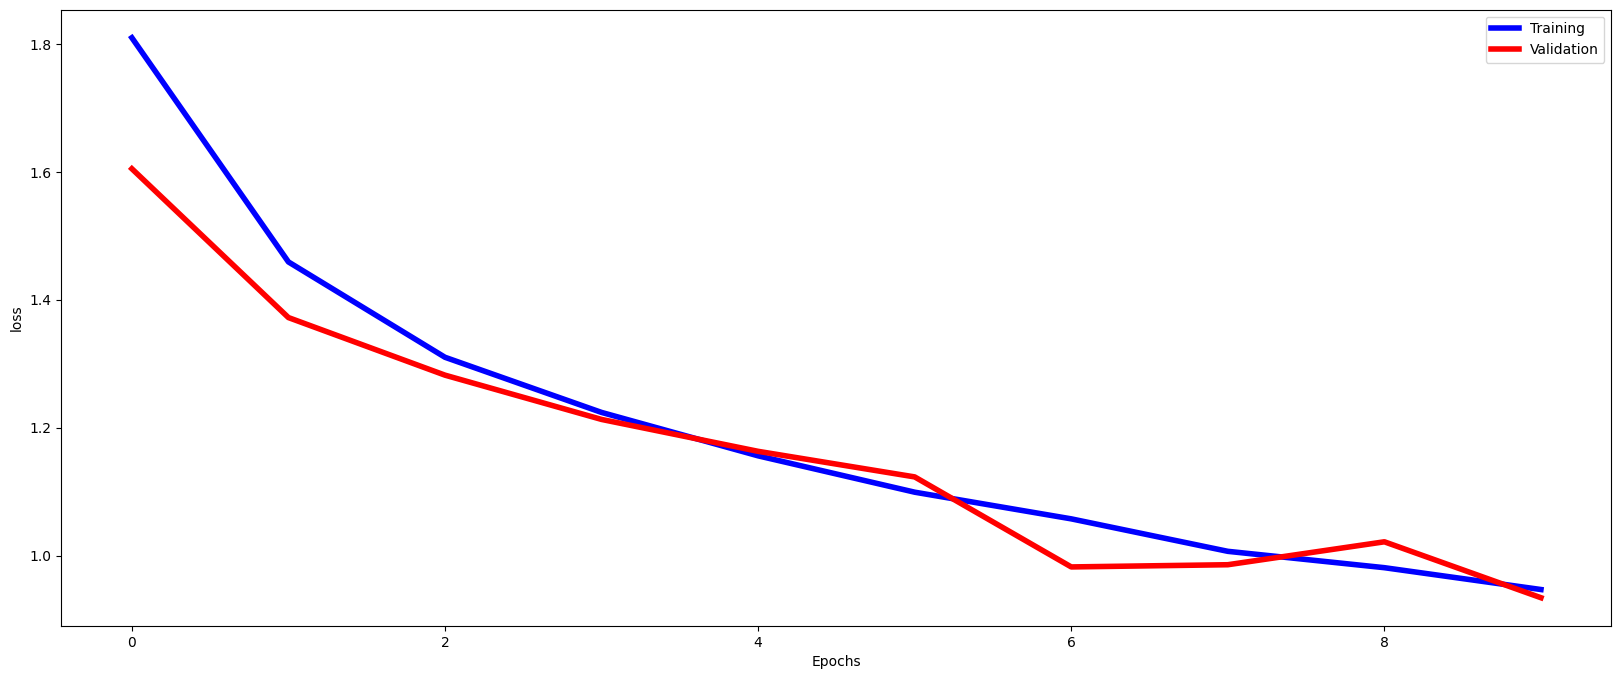

In [63]:
plot_history(history, plot_type='loss')

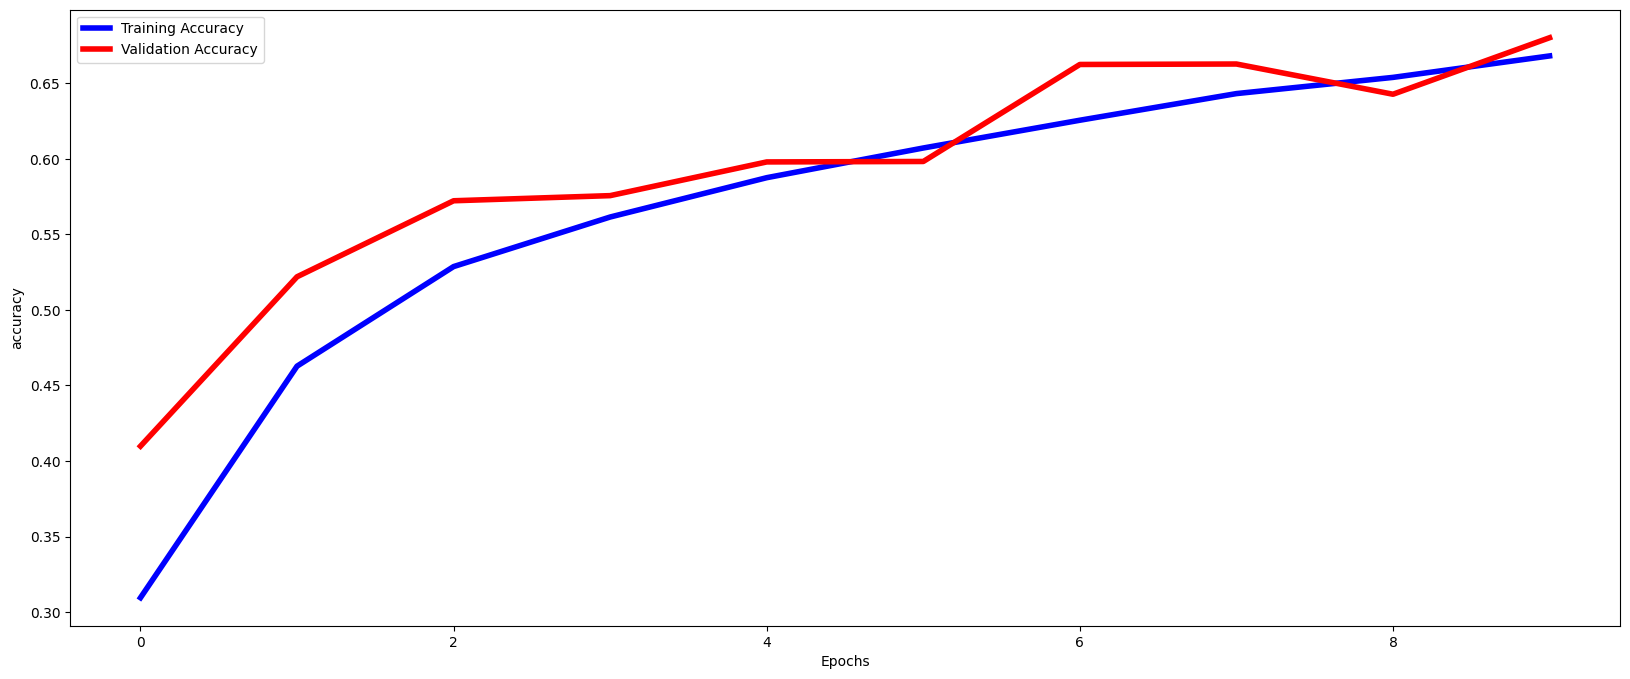

In [64]:
plot_history(history, plot_type='accuracy')

Finally, we check the model on the test set. We use F1-score, top-3 accuracy, and a confusion matrix.

In [65]:
predictions = model.predict(X_test)

# Convert labels to simple class numbers.
y_test_labels = np.asarray(y_test).reshape(-1)
predicted_labels = convert_predictions(predictions)

baseline_f1 = f1_score(y_test_labels, predicted_labels, average='weighted')

top3_metric = tf.keras.metrics.TopKCategoricalAccuracy(k=3)
top3_metric.update_state(y_test_enc, predictions)
baseline_top3 = top3_metric.result().numpy()

print('Weighted F1-score is %.2f' % baseline_f1)
print('Top-3 accuracy is %.2f' % baseline_top3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Weighted F1-score is 0.67
Top-3 accuracy is 0.91


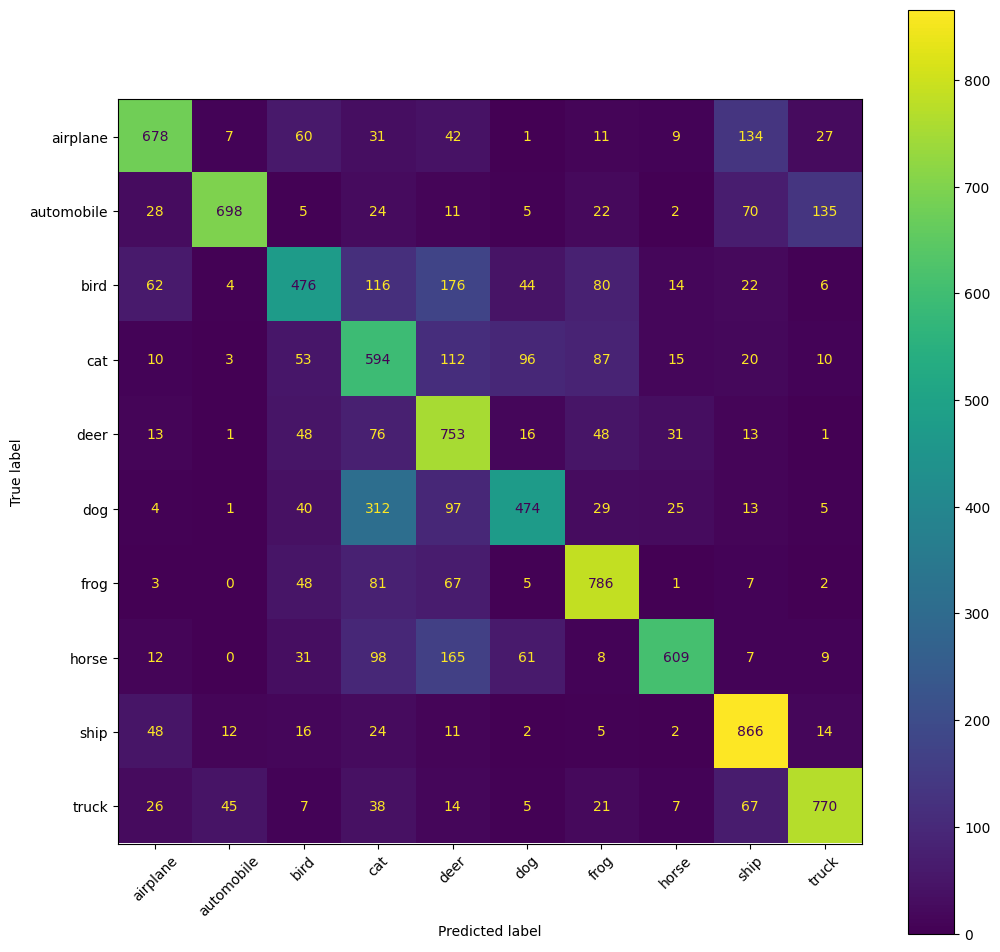

In [66]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(y_test_labels,
                                        predicted_labels,
                                        display_labels=class_names,
                                        xticks_rotation=45,
                                        ax=ax)
plt.show()

In [67]:
# Save results for later sections.
baseline_model = model
baseline_predictions = predictions

# Investigate the Effects of Different Parameters

Now we change some CNN parameters and check the result. We use small K-Fold validation, like in the lab, so the tests stay simple.

### Some Handy Functions

These functions train a few models and compare their F1-score. The plots use short labels, so they are easy to read.

In [77]:
import time
from IPython.display import display
from sklearn.model_selection import KFold


def kfold_validation(no_folds: int=3, plot_results: bool=True,
                     model_params: dict={}, training_params: dict={},
                     max_samples: int=6000):
  validation_set_accuracy = []
  models = []
  training_times = []

  if plot_results:
    verbose = 2
  else:
    verbose = 0

  # Use a small part of the data to keep K-Fold fast.
  if max_samples and max_samples < X_train.shape[0]:
    train_data = X_train[:max_samples]
    train_labels = y_train[:max_samples]
    train_labels_enc = y_train_enc[:max_samples]
  else:
    train_data = X_train
    train_labels = y_train
    train_labels_enc = y_train_enc

  # Clean old plot names from earlier runs.
  wrong_keys = ['Kernel Size', 'Stride', 'Filters', 'Pooling Type', 'Pooling Window', 'Depth']
  for key in wrong_keys:
    model_params.pop(key, None)

  itr = 0
  kf = KFold(n_splits=no_folds, shuffle=True, random_state=42)
  for train_index, val_index in kf.split(train_data, train_labels):
    train_set, y_train_set = train_data[train_index], train_labels_enc[train_index]
    val_set, y_val = train_data[val_index], train_labels_enc[val_index]

    # First, create a new model.
    model = create_model(**model_params)

    # Finally, let's fit the model.
    start_time = time.time()
    history = model.fit(train_set, y_train_set,
                        validation_data=(val_set, y_val),
                        callbacks=[early_stopping],
                        verbose=verbose,
                        **training_params)
    training_times.append(time.time() - start_time)

    # Finally, let's test on validation data.
    pred_val = model.predict(val_set, verbose=0)
    f1 = f1_score(convert_predictions(y_val), convert_predictions(pred_val), average='weighted')

    validation_set_accuracy.append(f1)
    models.append(model)

    if plot_results:
      print('Fold %d F1-score is %.3f' % (itr + 1, f1))
      plot_history(history, plot_type='accuracy')

    itr += 1

  # Convert to numpy array.
  validation_set_accuracy = np.array(validation_set_accuracy)
  training_times = np.array(training_times)

  # Return the best model.
  ind = np.argmax(validation_set_accuracy)
  best_model = models[ind]

  # Delete remaining models.
  models.remove(best_model)
  for m in models:
    del m

  # Print the results.
  if plot_results:
    print('Average F1-Score over validation set is %.2f' % validation_set_accuracy.mean())
    print('STD of F1-Score over validation set is %.2f' % validation_set_accuracy.std())
    print('Average training time is %.1f seconds' % training_times.mean())

  return best_model, validation_set_accuracy.mean(), validation_set_accuracy.std(), training_times.mean()


def show_experiment_plot(results_df, parameter_name: str=''):
  plt.figure(figsize=(8, 5))
  plt.plot(results_df['Short Label'], results_df['Validation F1'], marker='o', lw=2)
  plt.plot(results_df['Short Label'], results_df['Test F1'], marker='o', lw=2)
  plt.xlabel(parameter_name)
  plt.ylabel('F1-Score')
  plt.grid(True)
  plt.legend(['Validation F1', 'Test F1'])
  plt.tight_layout()
  plt.show()


def evaluate_efect_param(parameter_type: str='kfold', parameter_name: str='', values_list: list=[],
                         labels_list: list=None, full_settings: list=None, plot_name: str=None):
  scores_val = []
  scores_test = []
  times = []
  models = []

  if labels_list is None:
    labels_list = [str(v) for v in values_list]
  if full_settings is None:
    full_settings = [str(v) for v in values_list]
  if plot_name is None:
    plot_name = parameter_name

  y_test_labels = np.asarray(y_test).reshape(-1)

  for itr, val in enumerate(values_list):

      if parameter_type == 'kfold':
        kfold_params[parameter_name] = val
      elif parameter_type == 'model_params':
        kfold_params['model_params'][parameter_name] = val
      elif parameter_type == 'training_params':
        kfold_params['training_params'][parameter_name] = val

      model, validation_set_accuracy_mean, validation_set_accuracy_std, training_time = kfold_validation(**kfold_params)

      scores_val.append(validation_set_accuracy_mean)
      times.append(training_time)

      predictions = model.predict(X_test, verbose=0)
      score_test = f1_score(y_test_labels, convert_predictions(predictions), average='weighted')
      scores_test.append(score_test)

      models.append(model)
      print('Val: %s, Validation Score: %.3f, Test Score: %.3f, Time: %.1fs'
            % (labels_list[itr], validation_set_accuracy_mean, score_test, training_time))

  results_df = pd.DataFrame({
      'Short Label': labels_list,
      'Full Setting': full_settings,
      'Validation F1': scores_val,
      'Test F1': scores_test,
      'Training Time (sec)': times,
  })

  show_experiment_plot(results_df, parameter_name=plot_name)
  display(results_df)

  ind = np.argmax(scores_val)
  best_model = models[ind]
  best_val = values_list[ind]

  models.remove(best_model)
  for m in models:
    del m

  print('Best value is %s' % labels_list[ind])
  return best_model, best_val, results_df


In [78]:
kfold_params = {
    'no_folds': 3,
    'plot_results': False,
    'max_samples': 6000,
    'model_params': {
        'hidden_layers': baseline_architecture,
        'activation_func': 'relu',
        'learning_rate': 0.001,
        'dropout_rate': 0.2,
    },
    'training_params': {
        'batch_size': 128,
        'epochs': 3,
    },
}

### <font color="blue">Effect of Receptive Field Size</font>

Here we change the kernel size. A bigger kernel can see a larger part of the image.

Val: K3, Validation Score: 0.204, Test Score: 0.232, Time: 3.3s
Val: K5, Validation Score: 0.200, Test Score: 0.249, Time: 3.0s
Val: K7, Validation Score: 0.197, Test Score: 0.211, Time: 2.6s


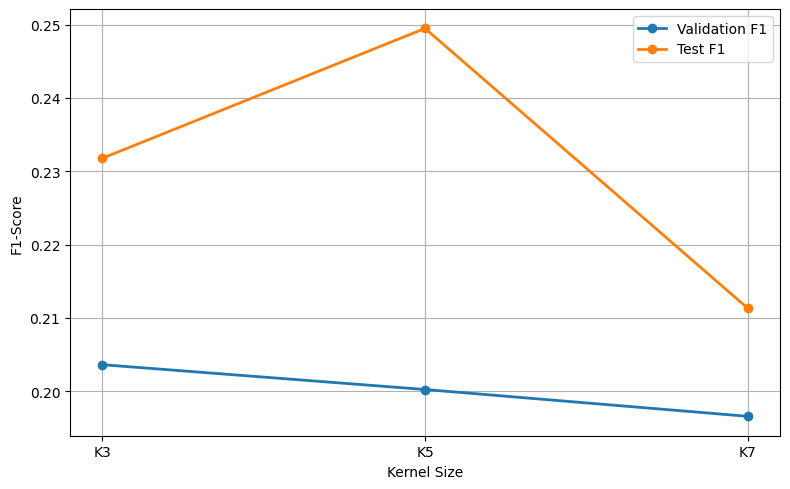

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,K3,3x3 kernels,0.203623,0.231772,3.292690
1,K5,5x5 kernels,0.200238,0.249489,3.044245
2,K7,7x7 first kernel,0.196581,0.211321,2.646076


Best value is K3


In [79]:
kernel_labels = ['K3', 'K5', 'K7']

kernel_architectures = [
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_5x5_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_5x5_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_7x7_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
]

kernel_settings = [
    '3x3 kernels',
    '5x5 kernels',
    '7x7 first kernel'
]

model, best_kernel_architecture, kernel_results = evaluate_efect_param(
    parameter_type='model_params',
    parameter_name='hidden_layers',
    values_list=kernel_architectures,
    labels_list=kernel_labels,
    full_settings=kernel_settings,
    plot_name='Kernel Size'
)

kfold_params['model_params']['hidden_layers'] = best_kernel_architecture

A bigger kernel gives more capacity because it reads more pixels at once. It can overfit more and train slower. The best kernel is kept because it has the best validation F1-score.

### <font color="blue">Effect Convolution Stride</font>

Now we change the stride in the first convolution layer. A larger stride makes the feature maps smaller.

Val: S1, Validation Score: 0.262, Test Score: 0.272, Time: 3.1s
Val: S2, Validation Score: 0.169, Test Score: 0.214, Time: 1.9s
Val: S3, Validation Score: 0.229, Test Score: 0.263, Time: 1.6s


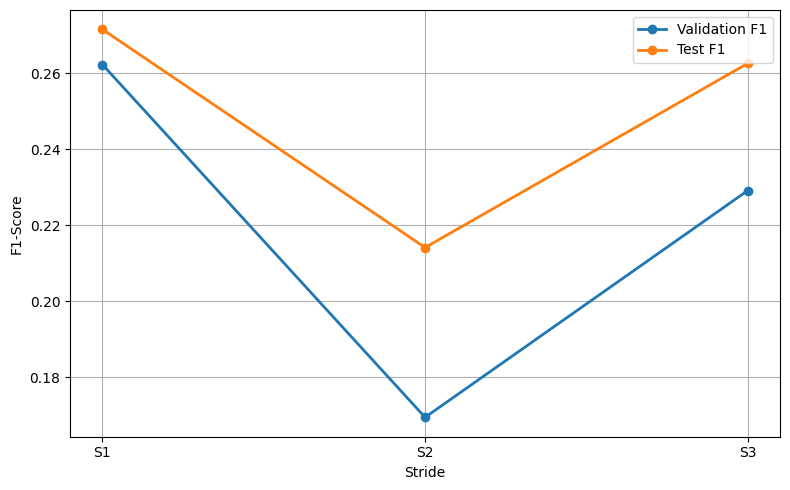

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,S1,Stride 1: Conv2D_3x3_32_1 -> MaxPooling2D_2x2_...,0.262354,0.271618,3.073905
1,S2,Stride 2: Conv2D_3x3_32_2 -> MaxPooling2D_2x2_...,0.169409,0.214145,1.906668
2,S3,Stride 3: Conv2D_3x3_32_3 -> Conv2D_3x3_64_1 -...,0.229159,0.262667,1.599576


Best value is S1


In [80]:
stride_labels = ['S1', 'S2', 'S3']
stride_architectures = [
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_2', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_3', 'Conv2D_3x3_64_1', 'Flatten', 'Dense_64'],
]
stride_settings = ['Stride 1: ' + ' -> '.join(stride_architectures[0]),
                   'Stride 2: ' + ' -> '.join(stride_architectures[1]),
                   'Stride 3: ' + ' -> '.join(stride_architectures[2])]

model, best_stride_architecture, stride_results = evaluate_efect_param(parameter_type='model_params',
                                                                       parameter_name='hidden_layers',
                                                                       values_list=stride_architectures,
                                                                       labels_list=stride_labels,
                                                                       full_settings=stride_settings,
                                                                       plot_name='Stride')
kfold_params['model_params']['hidden_layers'] = best_stride_architecture

A larger stride lowers training time because the maps become smaller. If stride is too large, the model may lose details and underfit. We keep the stride with the best validation performance.

### <font color="blue">Effect Of Number of Filters</font>

Now we change the number of filters. More filters can learn more image patterns.

Val: F16, Validation Score: 0.178, Test Score: 0.198, Time: 2.1s
Val: F32, Validation Score: 0.251, Test Score: 0.287, Time: 3.1s
Val: F64, Validation Score: 0.185, Test Score: 0.248, Time: 6.3s


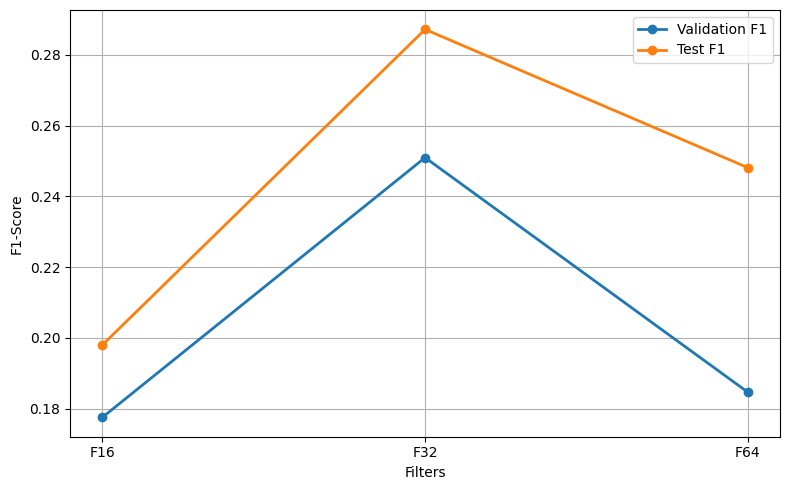

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,F16,Base 16 filters: Conv2D_3x3_16_1 -> MaxPooling...,0.177559,0.198027,2.082846
1,F32,Base 32 filters: Conv2D_3x3_32_1 -> MaxPooling...,0.250968,0.287209,3.078915
2,F64,Base 64 filters: Conv2D_3x3_64_1 -> MaxPooling...,0.184685,0.248140,6.308208


Best value is F32


In [81]:
filter_labels = ['F16', 'F32', 'F64']
filter_architectures = [
    ['Conv2D_3x3_16_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_128_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
]
filter_settings = ['Base 16 filters: ' + ' -> '.join(filter_architectures[0]),
                   'Base 32 filters: ' + ' -> '.join(filter_architectures[1]),
                   'Base 64 filters: ' + ' -> '.join(filter_architectures[2])]

model, best_filter_architecture, filter_results = evaluate_efect_param(parameter_type='model_params',
                                                                       parameter_name='hidden_layers',
                                                                       values_list=filter_architectures,
                                                                       labels_list=filter_labels,
                                                                       full_settings=filter_settings,
                                                                       plot_name='Filters')
kfold_params['model_params']['hidden_layers'] = best_filter_architecture

More filters increase model capacity and may improve F1-score. Too many filters can overfit and need more time. We keep the filter size with the best validation score.

### <font color="blue">Effect Of Pooling type</font>

Here we compare max pooling, average pooling, and no pooling. Pooling makes the image maps smaller.

Val: MAX, Validation Score: 0.226, Test Score: 0.243, Time: 3.5s
Val: AVG, Validation Score: 0.179, Test Score: 0.172, Time: 3.1s
Val: NONE, Validation Score: 0.163, Test Score: 0.194, Time: 11.3s


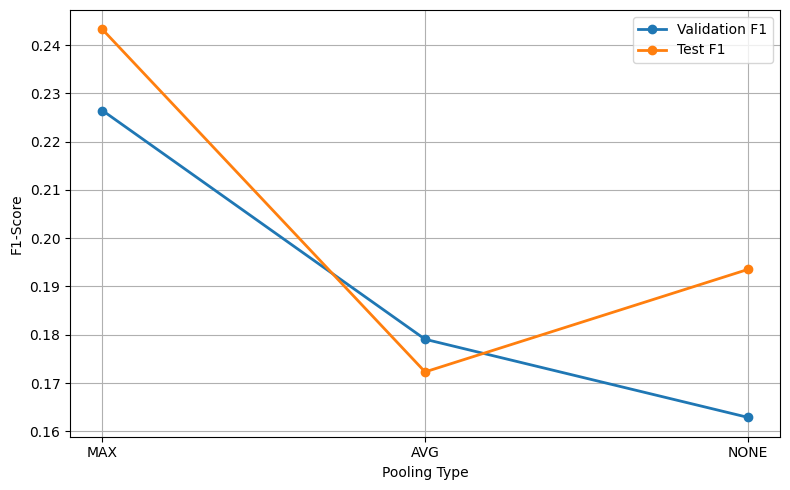

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,MAX,Max pooling: Conv2D_3x3_32_1 -> MaxPooling2D_2...,0.226455,0.243256,3.459813
1,AVG,Average pooling: Conv2D_3x3_32_1 -> AveragePoo...,0.179067,0.172304,3.116557
2,NONE,No pooling: Conv2D_3x3_32_1 -> Conv2D_3x3_64_1...,0.162897,0.193523,11.253765


Best value is MAX


In [82]:
pooling_labels = ['MAX', 'AVG', 'NONE']
pooling_architectures = [
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'AveragePooling2D_2x2_0', 'Conv2D_3x3_64_1', 'AveragePooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'Conv2D_3x3_64_1', 'Conv2D_3x3_64_1', 'Flatten', 'Dense_64'],
]
pooling_settings = ['Max pooling: ' + ' -> '.join(pooling_architectures[0]),
                    'Average pooling: ' + ' -> '.join(pooling_architectures[1]),
                    'No pooling: ' + ' -> '.join(pooling_architectures[2])]

model, best_pooling_architecture, pooling_results = evaluate_efect_param(parameter_type='model_params',
                                                                         parameter_name='hidden_layers',
                                                                         values_list=pooling_architectures,
                                                                         labels_list=pooling_labels,
                                                                         full_settings=pooling_settings,
                                                                         plot_name='Pooling Type')
kfold_params['model_params']['hidden_layers'] = best_pooling_architecture

Max pooling keeps the strongest signal. Average pooling smooths the map. No pooling has more capacity, but it can overfit and train slower. We keep the best validation result.

### <font color="blue">Effect Of Pooling Window Size</font>

Now we change the pooling window size. A larger window reduces the feature map faster.

Val: W2, Validation Score: 0.207, Test Score: 0.219, Time: 3.1s
Val: W3, Validation Score: 0.163, Test Score: 0.185, Time: 3.0s
Val: W4, Validation Score: 0.202, Test Score: 0.235, Time: 3.1s


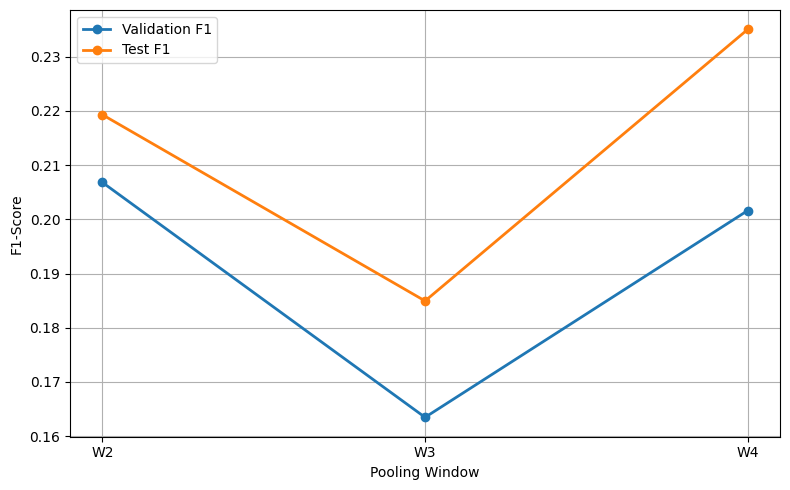

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,W2,2x2 pooling: Conv2D_3x3_32_1 -> MaxPooling2D_2...,0.206798,0.219284,3.145391
1,W3,3x3 pooling: Conv2D_3x3_32_1 -> MaxPooling2D_3...,0.163475,0.184938,3.016167
2,W4,4x4 pooling: Conv2D_3x3_32_1 -> MaxPooling2D_4...,0.201613,0.235020,3.149082


Best value is W2


In [83]:
pool_window_labels = ['W2', 'W3', 'W4']
pool_window_architectures = [
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'MaxPooling2D_3x3_2', 'Conv2D_3x3_64_1', 'MaxPooling2D_3x3_2', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'MaxPooling2D_4x4_2', 'Conv2D_3x3_64_1', 'Flatten', 'Dense_64'],
]
pool_window_settings = ['2x2 pooling: ' + ' -> '.join(pool_window_architectures[0]),
                        '3x3 pooling: ' + ' -> '.join(pool_window_architectures[1]),
                        '4x4 pooling: ' + ' -> '.join(pool_window_architectures[2])]

model, best_pool_window_architecture, pool_window_results = evaluate_efect_param(parameter_type='model_params',
                                                                                parameter_name='hidden_layers',
                                                                                values_list=pool_window_architectures,
                                                                                labels_list=pool_window_labels,
                                                                                full_settings=pool_window_settings,
                                                                                plot_name='Pooling Window')
kfold_params['model_params']['hidden_layers'] = best_pool_window_architecture

A larger pooling window trains faster because it makes the maps smaller. It can remove useful details and underfit. The best value balances training time and performance.

### <font color="blue">Effect Of Network Depth</font>

Finally, we compare shallow, medium, and deep CNN models.

Val: D1, Validation Score: 0.224, Test Score: 0.290, Time: 2.7s
Val: D2, Validation Score: 0.222, Test Score: 0.248, Time: 3.2s
Val: D3, Validation Score: 0.179, Test Score: 0.201, Time: 3.5s


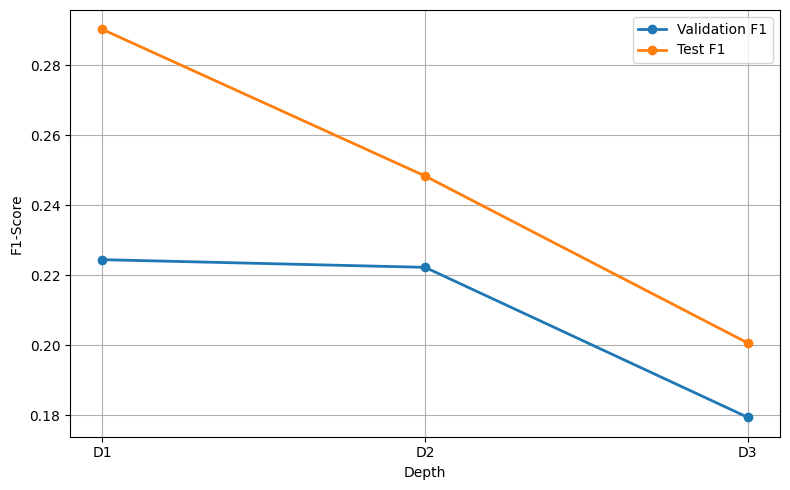

,Short Label,Full Setting,Validation F1,Test F1,Training Time (sec)
0,D1,Shallow CNN: Conv2D_3x3_32_1 -> MaxPooling2D_2...,0.224456,0.290164,2.741667
1,D2,Medium CNN: Conv2D_3x3_32_1 -> MaxPooling2D_2x...,0.222265,0.248323,3.221380
2,D3,Deep CNN: Conv2D_3x3_32_1 -> MaxPooling2D_2x2_...,0.179465,0.200681,3.459265


Best value is D1


In [84]:
depth_labels = ['D1', 'D2', 'D3']
depth_architectures = [
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Flatten', 'Dense_64'],
    ['Conv2D_3x3_32_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'MaxPooling2D_2x2_0', 'Conv2D_3x3_64_1', 'Flatten', 'Dense_64'],
]
depth_settings = ['Shallow CNN: ' + ' -> '.join(depth_architectures[0]),
                  'Medium CNN: ' + ' -> '.join(depth_architectures[1]),
                  'Deep CNN: ' + ' -> '.join(depth_architectures[2])]

model, best_depth_architecture, depth_results = evaluate_efect_param(parameter_type='model_params',
                                                                     parameter_name='hidden_layers',
                                                                     values_list=depth_architectures,
                                                                     labels_list=depth_labels,
                                                                     full_settings=depth_settings,
                                                                     plot_name='Depth')
kfold_params['model_params']['hidden_layers'] = best_depth_architecture

A shallow CNN is faster but may underfit. A deep CNN has more capacity, but it can overfit and needs more time. We keep the depth with the best validation F1-score.

# Data Augmentation

Data augmentation creates new training images from our images. It can help the model see more cases and reduce overfitting.

We have several options to create new images from the existing images. Here, we use simple Keras generators.

In [102]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Random crop helper for CIFAR-10 size images.
def random_crop(image):
  image = tf.image.resize_with_crop_or_pad(image, 36, 36)
  image = tf.image.random_crop(image, size=(32, 32, 3))
  return image

# Flip images left-right and up-down.
flip_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
)

# Rotate images a little.
rotation_datagen = ImageDataGenerator(
    rotation_range=20,
)

# Crop images and resize back to the same size.
crop_datagen = ImageDataGenerator(
    preprocessing_function=random_crop,
)

# Change image brightness.
brightness_datagen = ImageDataGenerator(
    brightness_range=[0.8, 1.2],
)

# Put several changes together for training.
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1]
)

# Validation data should stay unchanged.
val_datagen = ImageDataGenerator()

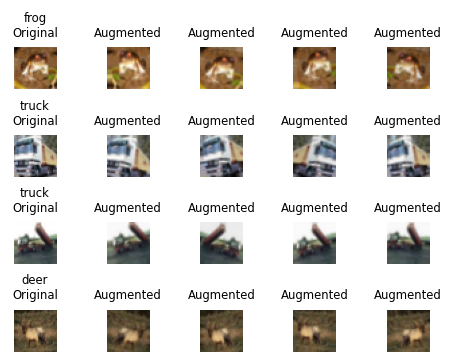

In [103]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use a separate generator only for showing images.
preview_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    brightness_range=[0.90, 1.10],
    fill_mode="nearest"
)

# Convert image to 0-255 for ImageDataGenerator.
def image_to_255(image):
    image = image.astype("float32")
    if image.max() <= 1.5:
        image = image * 255.0
    return image

# Convert image to 0-1 for showing with plt.imshow.
def image_to_show(image):
    image = image.astype("float32")
    if image.max() > 1.5:
        image = image / 255.0
    return np.clip(image, 0, 1)

sample_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(4, 5, figsize=(4, 3), dpi=120)

for row, image_index in enumerate(sample_indices):
    original_image = X_train[image_index]
    label_index = np.argmax(y_train_enc[image_index])

    # Show original image.
    axes[row, 0].imshow(image_to_show(original_image))
    axes[row, 0].set_title(class_names[label_index] + "\nOriginal", fontsize=7)
    axes[row, 0].axis("off")

    # Make 4 augmented images.
    image_batch = np.expand_dims(image_to_255(original_image), axis=0)
    aug_iterator = preview_datagen.flow(
        image_batch,
        batch_size=1,
        shuffle=False,
        seed=42 + row
    )

    for col in range(1, 5):
        augmented_image = next(aug_iterator)[0]

        axes[row, col].imshow(image_to_show(augmented_image))
        axes[row, col].set_title("Augmented", fontsize=7)
        axes[row, col].axis("off")

plt.tight_layout(pad=0.6)
plt.show()

The next code shows how we would train a CNN with augmented data. 

In [108]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Split the normalized training data into train and validation parts.
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train,
    y_train_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Light augmentation for normalized CIFAR-10 images.
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation data must stay unchanged.
val_datagen = ImageDataGenerator()

# Build the exact same baseline model.
baseline_architecture = [
    'Conv2D_3x3_32_1',
    'MaxPooling2D_2x2_0',
    'Conv2D_3x3_64_1',
    'MaxPooling2D_2x2_0',
    'Conv2D_3x3_64_1',
    'Flatten',
    'Dense_64',
    'Dense_32',
]

augmented_baseline_model = create_model(
    hidden_layers=baseline_architecture,
    activation_func='relu',
    learning_rate=0.001,
    dropout_rate=0.2
)

augmented_baseline_model.summary()

# Create iterators for augmented train data and normal validation data.
train_iterator = train_datagen.flow(
    X_train_aug,
    y_train_aug,
    batch_size=64,
    shuffle=True
)

val_iterator = val_datagen.flow(
    X_val_aug,
    y_val_aug,
    batch_size=64,
    shuffle=False
)

# Train the exact same baseline model on augmented and normalized data.
history_augmented_baseline = augmented_baseline_model.fit(
    train_iterator,
    validation_data=val_iterator,
    epochs=10,
    verbose=2
)

Model: "sequential_103"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_237 (Conv2D)             │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_280 (Dropout)           │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_164               │ (None, 15, 15, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_238 (Conv2D)             │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_281 (Dropout)           │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_165               │ (None, 6, 6, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_239 (Conv2D)             │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_282 (Dropout)           │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_103 (Flatten)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_212 (Dense)               │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_283 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_213 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_214 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,330 (485.66 KB)

 Trainable params: 124,330 (485.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 - 13s - 21ms/step - accuracy: 0.2827 - loss: 1.8942 - val_accuracy: 0.3917 - val_loss: 1.6602
Epoch 2/10
625/625 - 11s - 18ms/step - accuracy: 0.4137 - loss: 1.5895 - val_accuracy: 0.4818 - val_loss: 1.4403
Epoch 3/10
625/625 - 12s - 19ms/step - accuracy: 0.4663 - loss: 1.4710 - val_accuracy: 0.5023 - val_loss: 1.4172
Epoch 4/10
625/625 - 12s - 19ms/step - accuracy: 0.4969 - loss: 1.3931 - val_accuracy: 0.5575 - val_loss: 1.2655
Epoch 5/10
625/625 - 12s - 20ms/step - accuracy: 0.5233 - loss: 1.3301 - val_accuracy: 0.5771 - val_loss: 1.2007
Epoch 6/10
625/625 - 12s - 20ms/step - accuracy: 0.5371 - loss: 1.2911 - val_accuracy: 0.5834 - val_loss: 1.1948
Epoch 7/10
625/625 - 12s - 19ms/step - accuracy: 0.5522 - loss: 1.2500 - val_accuracy: 0.5986 - val_loss: 1.1448
Epoch 8/10
625/625 - 13s - 20ms/step - accuracy: 0.5706 - loss: 1.2167 - val_accuracy: 0.6260 - val_loss: 1.0918
Epoch 9/10
625/625 - 13s - 21ms/step - accuracy: 0.5759 - loss: 1.1956 - val_accuracy: 0.6266 - 

In [111]:
from sklearn.metrics import f1_score
import numpy as np

# Predict on normalized test data.
augmented_baseline_predictions = augmented_baseline_model.predict(X_test, verbose=0)

# Convert predictions to labels.
y_test_labels = np.argmax(y_test_enc, axis=1)
y_pred_labels = np.argmax(augmented_baseline_predictions, axis=1)

# Weighted F1-score.
augmented_baseline_f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')
print("Weighted F1-score:", augmented_baseline_f1)

# Top-3 accuracy.
top3 = np.argsort(augmented_baseline_predictions, axis=1)[:, -3:]
augmented_baseline_top3 = np.mean(
    [y_test_labels[i] in top3[i] for i in range(len(y_test_labels))]
)
print("Top-3 accuracy:", augmented_baseline_top3)

Weighted F1-score: 0.6204157136246921
Top-3 accuracy: 0.8916


These plots would show if augmentation helps the validation score and reduces overfitting.

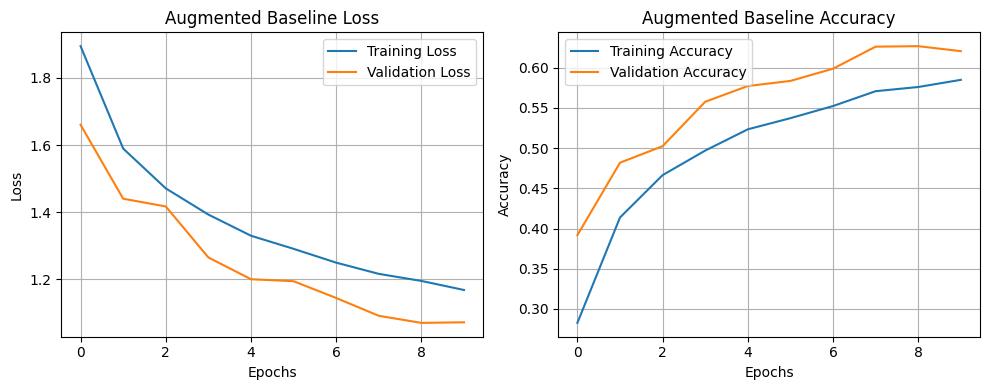

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history_augmented_baseline.history['loss'], label='Training Loss')
plt.plot(history_augmented_baseline.history['val_loss'], label='Validation Loss')
plt.title('Augmented Baseline Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)

# Check which key exists for accuracy in the history
acc_key = 'accuracy' if 'accuracy' in history_augmented_baseline.history else 'categorical_accuracy'

plt.plot(history_augmented_baseline.history[acc_key], label='Training Accuracy')
plt.plot(history_augmented_baseline.history['val_' + acc_key], label='Validation Accuracy')
plt.title('Augmented Baseline Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Augmentation would make the training set more varied. It may make training slower, but it can help the model work better on new images.

# Transfer Learning

Transfer learning uses a model that was trained before on a large dataset. This can help when our own dataset is small or training time is limited.

This technique is called transfer learning. Keras gives us pretrained models like VGG19.

In [113]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import Lambda

def create_transfer_model(base_model_name: str='VGG19', input_size=X_train.shape[1:],
                          no_classes=y_train_enc.shape[1], learning_rate: float=0.001,
                          dense_neurons: int=128, dropout_rate: float=0.5):
  if base_model_name == 'VGG19':
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_size)
  else:
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_size)

  # Freeze the pretrained base layers.
  for layer in base_model.layers:
    layer.trainable = False

  model = Sequential()
  model.add(Input(shape=input_size))
  model.add(Lambda(lambda image: preprocess_input(image * 255.0)))
  model.add(base_model)
  model.add(Flatten())
  model.add(Dense(dense_neurons, activation='relu'))
  model.add(Dropout(dropout_rate))
  model.add(Dense(no_classes, activation='softmax'))

  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  model.compile(
      loss='categorical_crossentropy',
      optimizer=optimizer,
      metrics=['accuracy'],
  )

  return model

#### VGG19 Model

VGG19 is chosen because it is a clear and common CNN model. Here, we use it as feature extraction. The convolution base layers from VGG19 are frozen, and only the new classifier layers would train.

In [115]:
transfer_model_vgg = create_transfer_model(base_model_name='VGG19',
                                           learning_rate=0.001,
                                           dense_neurons=128,
                                           dropout_rate=0.5)

transfer_model_vgg.summary()

history_vgg = transfer_model_vgg.fit(
      X_train,
      y_train_enc,
      batch_size=64,
      epochs=5,
      validation_split=0.2,
      callbacks=[early_stopping],
      verbose=2,
  )

Model: "sequential_105"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_105 (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_217 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_285 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_218 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,091,338 (76.64 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/5
625/625 - 141s - 225ms/step - accuracy: 0.3431 - loss: 3.1408 - val_accuracy: 0.5023 - val_loss: 1.4219
Epoch 2/5
625/625 - 100s - 160ms/step - accuracy: 0.4561 - loss: 1.5360 - val_accuracy: 0.5581 - val_loss: 1.2668
Epoch 3/5
625/625 - 185s - 296ms/step - accuracy: 0.5077 - loss: 1.3938 - val_accuracy: 0.5835 - val_loss: 1.2084
Epoch 4/5
625/625 - 75s - 120ms/step - accuracy: 0.5386 - loss: 1.3048 - val_accuracy: 0.6021 - val_loss: 1.1464
Epoch 5/5
625/625 - 76s - 122ms/step - accuracy: 0.5594 - loss: 1.2477 - val_accuracy: 0.6125 - val_loss: 1.1211


In [117]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

# Predict probabilities on the test set.
transfer_predictions_vgg = transfer_model_vgg.predict(X_test, verbose=0)

# Convert one-hot labels and predicted probabilities to class labels.
y_test_labels = np.argmax(y_test_enc, axis=1)
y_pred_labels = np.argmax(transfer_predictions_vgg, axis=1)

# Weighted F1-score.
transfer_f1_vgg = f1_score(y_test_labels, y_pred_labels, average='weighted')
print("Weighted F1-score on test set:", transfer_f1_vgg)

# Top-3 accuracy.
top3 = np.argsort(transfer_predictions_vgg, axis=1)[:, -3:]
transfer_top3_vgg = np.mean(
    [y_test_labels[i] in top3[i] for i in range(len(y_test_labels))]
)
print("Top-3 accuracy on test set:", transfer_top3_vgg)

# Normal test accuracy from Keras.
test_loss, test_accuracy = transfer_model_vgg.evaluate(X_test, y_test_enc, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

# Confusion matrix.
cm = confusion_matrix(y_test_labels, y_pred_labels)
print("\nConfusion Matrix:")
print(cm)

# Classification report.
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

Weighted F1-score on test set: 0.4942669180088764
Top-3 accuracy on test set: 0.8112
Test loss: 1.4268641471862793
Test accuracy: 0.5019999742507935

Confusion Matrix:
[[579  29  39  58  18  13  16  38 134  76]
 [ 10 464   6  51  11  16  12  19  84 327]
 [ 97  17 271 109 140 136 138  61  24   7]
 [ 14  31  28 250  60 298 148  97  25  49]
 [ 35  10  55  65 352 119 154 177  13  20]
 [  6  14  39 131  48 535  51 149  13  14]
 [  9   7  33  83  64 124 649  16   7   8]
 [ 28   8  24  55  71 113  17 615  20  49]
 [123  64   5  41  11   7   7  11 599 132]
 [ 38 102   5  26   8   5  15  33  62 706]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.58      0.60      1000
           1       0.62      0.46      0.53      1000
           2       0.54      0.27      0.36      1000
           3       0.29      0.25      0.27      1000
           4       0.45      0.35      0.39      1000
           5       0.39      0.54      0.45      100

If we trained VGG19, these plots would show how the transfer model learns over epochs.

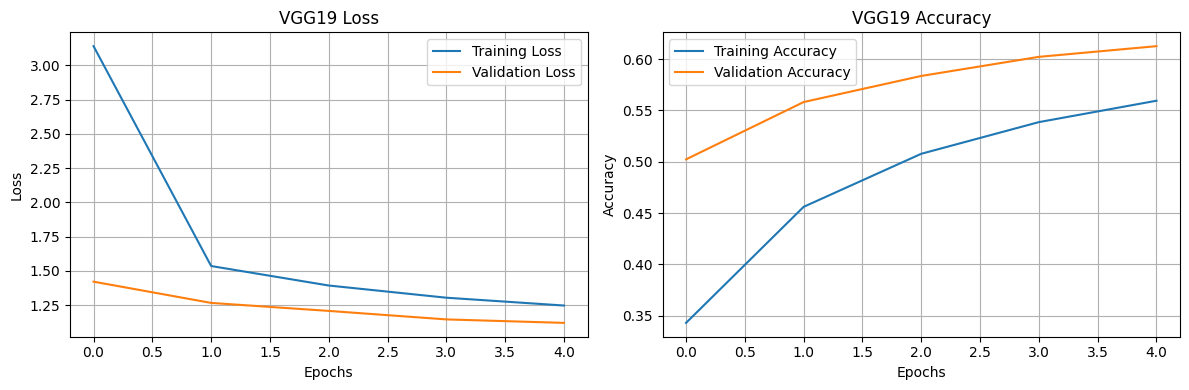

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax[0].plot(history_vgg.history['loss'], label='Training Loss')
ax[0].plot(history_vgg.history['val_loss'], label='Validation Loss')
ax[0].set_title('VGG19 Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].grid(True)
ax[0].legend()

# Accuracy plot
acc_key = 'accuracy' if 'accuracy' in history_vgg.history else 'categorical_accuracy'

ax[1].plot(history_vgg.history[acc_key], label='Training Accuracy')
ax[1].plot(history_vgg.history['val_' + acc_key], label='Validation Accuracy')
ax[1].set_title('VGG19 Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

The VGG19 transfer learning model did not perform better than the baseline CNN. This is because VGG19 was trained on larger ImageNet images and the base layers were frozen, so it could not fully adapt to our small dataset. The baseline CNN is simpler and better suited to these small images, so it gives higher accuracy on this task.

# Discussion Question: CNNs vs MLPs

CNNs are more parameter-efficient than MLPs because they use **local connections** and **shared weights**. In images, nearby pixels are strongly related, so a CNN looks at small regions and uses the same filter across the whole image. This allows the model to learn useful features like edges and shapes with far fewer parameters.

In contrast, an MLP connects every input pixel to every neuron in the next layer. For high-dimensional images, this creates a very large number of parameters. As a result, the model needs more memory, more computation, and much more data to train well. It also becomes more likely to overfit.

An MLP could theoretically match CNN performance if it had enough neurons, enough layers, and a very large amount of training data. However, this is unrealistic in practice because the number of parameters would become extremely large, training would be very slow, and the model would need too much data and computing power.

CNNs are more practical for image tasks because they leverage the structure of images efficiently, while MLPs treat all pixels as independent inputs.